# Assignment 6: Artificial Neural Networks

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -- Generator to get unique figure ids --
def fig_id_generator():
    i = 1
    while True:
        yield i
        i += 1
fig_id = fig_id_generator()

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(o):
    return o * (1 - o)

class MLPBackpropagation:
    def __init__(self, n_in: int, n_hidden: list, n_out: int):
        self.layers = [n_in] + n_hidden + [n_out]
        self.weights = [np.random.randn(self.layers[i], self.layers[i+1]) * 0.1 
                        for i in range(len(self.layers) - 1)]
        self.biases = [np.zeros((1, self.layers[i+1])) for i in range(len(self.layers) - 1)]
        
        self.history_train_err = []
        self.history_val_err = []
        self.history_test_err = []
        self.history_weights = []
        self.history_biases = []
        self.history_cms = {}
        self.history_cost = []
            
    def forward(self, x):
        activations = [x]
        for i in range(len(self.weights)):
            net = np.dot(activations[-1], self.weights[i]) + self.biases[i]
            out = sigmoid(net)
            activations.append(out)
        return activations
    
    def backward(self, x, t, current_eta):
        activations = self.forward(x)
        o = activations[-1]
        error_output = t - o
        delta = [sigmoid_derivative(o) * error_output]
        
        for i in range(len(self.weights) - 1, 0, -1):
            error_hidden = np.dot(delta[-1], self.weights[i].T)
            d_hidden = sigmoid_derivative(activations[i]) * error_hidden
            delta.append(d_hidden)
            
        delta.reverse()
        for i in range(len(self.weights)):
            self.weights[i] += current_eta * np.dot(activations[i].T, delta[i])
            self.biases[i] += current_eta * delta[i]

    def predict(self, x):
        outputs = self.forward(x)
        return np.argmax(outputs[-1], axis=1)

    def calculate_accuracy(self, x, y_labels):
        if x is None or len(x) == 0:
            return 100.0
        predictions = self.predict(x)
        true_labels = np.argmax(y_labels, axis=1)
        return np.mean(predictions == true_labels) * 100

    def _get_confusion_matrix(self, y_true, y_pred):
        num_classes = self.layers[-1]
        cm = np.zeros((num_classes, num_classes), dtype=int)
        for i in range(num_classes):
            for j in range(num_classes):
                cm[i, j] = np.sum((y_true == i) & (y_pred == j))
        return cm

    def fit(self, X_train, y_train, X_val=None, y_val=None, X_test=None, y_test=None, 
            eta=0.1, alpha=1.0, LR_decay_freq=10**9, maxIter=1000, maxErr=-1.0, 
            percentOverfit=100.0, shuffle=True, cms_freq=None):
       
        self.history_train_err = []
        self.history_val_err = []
        self.history_test_err = []
        self.history_weights = []
        self.history_biases = []
        self.history_cms = {}
        self.history_cost = []
        
        curr_eta = eta
        for iteration in range(1, maxIter + 1):
            indices = np.arange(len(X_train))
            if shuffle:
                np.random.shuffle(indices)
                
            for i in indices:
                self.backward(X_train[i:i+1], y_train[i:i+1], curr_eta)
            
            if iteration % LR_decay_freq == 0:
                curr_eta *= alpha
                
            t_acc = self.calculate_accuracy(X_train, y_train)
            v_acc = self.calculate_accuracy(X_val, y_val)
            s_acc = self.calculate_accuracy(X_test, y_test)
            
            # Calculate SSE for current state
            activations_train = self.forward(X_train)
            o_train = activations_train[-1]
            sse_current = 0.5 * np.sum((y_train - o_train)**2)
            self.history_cost.append(sse_current)

            self.history_train_err.append(100.0 - t_acc)
            self.history_val_err.append(100.0 - v_acc)
            self.history_test_err.append(100.0 - s_acc)
            self.history_weights.append([w.copy() for w in self.weights])
            self.history_biases.append([b.copy() for b in self.biases])
            
            # Store confusion matrix history if requested
            if cms_freq and iteration % cms_freq == 0 and X_test is not None:
                y_true = np.argmax(y_test, axis=1)
                y_pred = self.predict(X_test)
                self.history_cms[iteration] = self._get_confusion_matrix(y_true, y_pred)
            
            if (100.0 - s_acc) <= maxErr or (t_acc - v_acc) >= percentOverfit:
                break

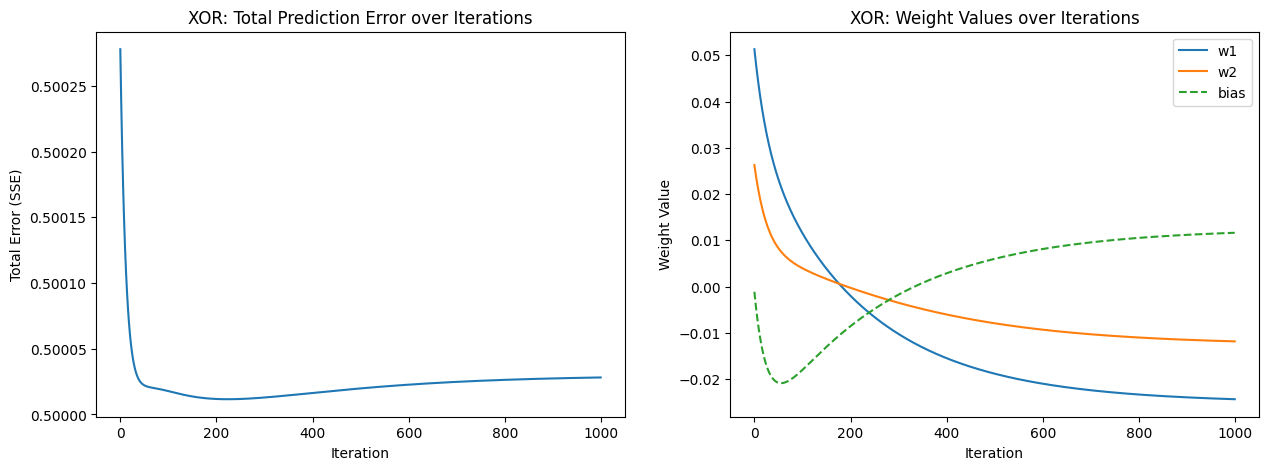

Final XOR Equation: y = sigmoid(-0.0243*x1 + -0.0118*x2 + 0.0116)


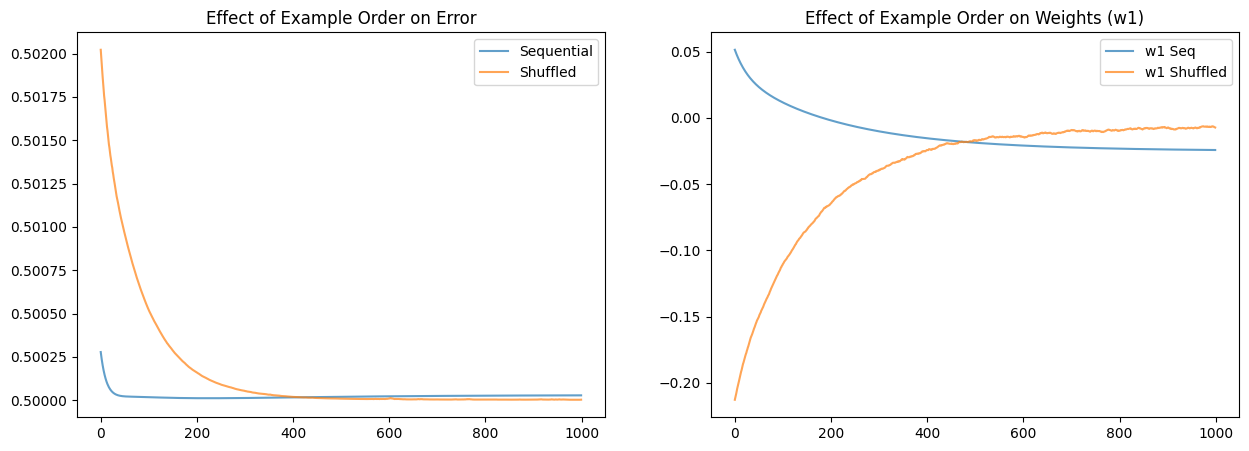


Final XNOR Equation: y = sigmoid(0.0254*x1 + 0.0134*x2 + -0.0132)


In [4]:
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([[0], [1], [1], [0]])

X_xnor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xnor = np.array([[1], [0], [0], [1]])

# Training for XOR
model_xor = MLPBackpropagation(2, [], 1)
model_xor.fit(X_xor, y_xor, X_val=X_xor, y_val=y_xor, X_test=X_xor, y_test=y_xor, 
          eta=0.1, maxIter=1000, maxErr=-1.0, percentOverfit=100.0, shuffle=False)
w_xor = np.array([w[0].flatten() for w in model_xor.history_weights])
b_xor = np.array([b[0].flatten() for b in model_xor.history_biases])

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(model_xor.history_cost)
plt.title("XOR: Total Prediction Error over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Total Error (SSE)")

plt.subplot(1, 2, 2)
plt.plot(w_xor[:, 0], label='w1')
plt.plot(w_xor[:, 1], label='w2')
plt.plot(b_xor, label='bias', linestyle='--')
plt.title("XOR: Weight Values over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Weight Value")
plt.legend()
plt.savefig(f"fig{next(fig_id)}.png", bbox_inches="tight")
plt.show()

w1, w2 = model_xor.weights[0].flatten()
b = model_xor.biases[0].flatten()[0]
print(f"Final XOR Equation: y = sigmoid({w1:.4f}*x1 + {w2:.4f}*x2 + {b:.4f})")

# Effect of order
model_xor_sf = MLPBackpropagation(2, [], 1)
model_xor_sf.fit(X_xor, y_xor, X_val=X_xor, y_val=y_xor, X_test=X_xor, y_test=y_xor, 
          eta=0.1, maxIter=1000, maxErr=-1.0, percentOverfit=100.0, shuffle=True)
w_xor_sf = np.array([w[0].flatten() for w in model_xor_sf.history_weights])
b_xor_sf = np.array([b[0].flatten() for b in model_xor_sf.history_biases])

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(model_xor.history_cost, label='Sequential', alpha=0.7)
plt.plot(model_xor_sf.history_cost, label='Shuffled', alpha=0.7)
plt.title("Effect of Example Order on Error")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(w_xor[:, 0], label='w1 Seq', alpha=0.7)
plt.plot(w_xor_sf[:, 0], label='w1 Shuffled', alpha=0.7)
plt.title("Effect of Example Order on Weights (w1)")
plt.legend()
plt.savefig(f"fig{next(fig_id)}.png", bbox_inches="tight")
plt.show()

# b. XNOR Equations
model_xnor = MLPBackpropagation(2, [], 1)
model_xnor.fit(X_xnor, y_xnor, X_val=X_xnor, y_val=y_xnor, X_test=X_xnor, y_test=y_xnor, 
          eta=0.1, maxIter=1000, maxErr=-1.0, percentOverfit=100.0, shuffle=False)

w1_xnor, w2_xnor = model_xnor.weights[0].flatten()
b_xnor = model_xnor.biases[0].flatten()[0]
print(f"\nFinal XNOR Equation: y = sigmoid({w1_xnor:.4f}*x1 + {w2_xnor:.4f}*x2 + {b_xnor:.4f})")

In [5]:
import pandas as pd

cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]

df1 = pd.read_csv("processed.cleveland.data", header=None, names=cols)
df2 = pd.read_csv("processed.hungarian.data", header=None, names=cols)
df3 = pd.read_csv("processed.switzerland.data", header=None, names=cols)
df4 = pd.read_csv("processed.va.data", header=None, names=cols)

df1_clean = df1.drop(columns=["slope", "ca"]).replace('?', np.nan).dropna(ignore_index=True).apply(pd.to_numeric)
df2_clean = df2.drop(columns=["slope", "ca"]).replace('?', np.nan).dropna(ignore_index=True).apply(pd.to_numeric)
df3_clean = df3.drop(columns=["slope", "ca"]).replace('?', np.nan).dropna(ignore_index=True).apply(pd.to_numeric)
df4_clean = df4.drop(columns=["slope", "ca"]).replace('?', np.nan).dropna(ignore_index=True).apply(pd.to_numeric)

def prepare_data_generic(df, multi_class=False, global_n_out=None):
    X = df.drop(columns=['num']).values
    if multi_class:
        y = df['num'].values.astype(int)
        y = np.clip(y, 0, global_n_out - 1)
        num_classes = global_n_out
    else:
        y = (df['num'].values > 0).astype(int)
        num_classes = 2
    
    y_oh = np.eye(num_classes)[y]
    X_norm = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0) + 1e-9)
    return X_norm, y_oh, y, num_classes

In [6]:
def evaluate_setting(params, multi_class=False, title_suffix=""):
    all_dfs = [df1_clean, df2_clean, df3_clean, df4_clean]
    all_names = ["Cleveland", "Hungarian", "Switzerland", "VA"]
    
    if multi_class:
        n_out = 5
    else:
        n_out = 2

    X, y_oh, y, _ = prepare_data_generic(df1_clean, multi_class, n_out)
    idx = np.random.permutation(len(X))
    tr_c = int(len(X) * params['Train_Seg'] / 100)
    va_c = tr_c + int(len(X) * params['Val_Seg'] / 100)
    
    X_tr, y_oh_tr, y_tr = X[idx[:tr_c]], y_oh[idx[:tr_c]], y[idx[:tr_c]]
    X_va, y_oh_va, y_va = X[idx[tr_c:va_c]], y_oh[idx[tr_c:va_c]], y[idx[tr_c:va_c]]
    X_te, y_oh_te, y_te = X[idx[va_c:]], y_oh[idx[va_c:]], y[idx[va_c:]]
    
    model = MLPBackpropagation(X.shape[1], params['n_hidden'], n_out)
    if params.get('init_zero', True):
        for i in range(len(model.weights)):
            model.weights[i].fill(0.0)
            model.biases[i].fill(0.0)
            
    model.fit(X_tr, y_oh_tr, X_va, y_oh_va, X_te, y_oh_te, 
              eta=params['eta'], alpha=params.get('alpha', 1.0), 
              LR_decay_freq=params.get('LR_decay_freq', 10**9),
              maxIter=params['maxIter'], maxErr=params['maxErr'], 
              percentOverfit=params['percentOverfit'], cms_freq=20)
            
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(model.history_train_err, label='Train')
    plt.plot(model.history_val_err, label='Val')
    plt.plot(model.history_test_err, label='Test')
    plt.title(f"Errors {title_suffix}"); plt.legend()
    plt.subplot(1, 2, 2); plt.imshow(model.weights[0], cmap='gray', aspect='auto')
    plt.title("Weights Layer 0"); plt.colorbar()
    plt.savefig(f"fig{next(fig_id)}.png", bbox_inches="tight")
    plt.show()
    
    print(f"Confusion Matrices (Cleveland Test Set):")
    for it, cm in model.history_cms.items():
        print(f"Iter {it}:\n{cm}")

    print("\nCross-Dataset training/testing:")
    for i in range(4):
        X_f, y_oh_f, y_f, _ = prepare_data_generic(all_dfs[i], multi_class, n_out)
        m_idx = np.random.permutation(len(X_f))
        tr_split = int(len(X_f)*0.8)
        m_temp = MLPBackpropagation(X_f.shape[1], params['n_hidden'], n_out)
        if params.get('init_zero', True):
            for layer_w in m_temp.weights: layer_w.fill(0.0)
            for layer_b in m_temp.biases: layer_b.fill(0.0)
        
        m_temp.fit(X_f[m_idx[:tr_split]], y_oh_f[m_idx[:tr_split]], 
                   eta=params['eta'], alpha=params.get('alpha', 1.0),
                   LR_decay_freq=params.get('LR_decay_freq', 10**9),
                   maxIter=params['maxIter'])
                   
        print(f"--- Trained on {all_names[i]} ---")
        for j in range(4):
            if i==j: continue
            X_ext, _, y_ext, _ = prepare_data_generic(all_dfs[j], multi_class, n_out)
            print(f"Tested on {all_names[j]} CM:\n{m_temp._get_confusion_matrix(y_ext, m_temp.predict(X_ext))}")

    print("\nCombined datasets training:")
    df_all = pd.concat(all_dfs)
    X_a, y_oh_a, y_a, _ = prepare_data_generic(df_all, multi_class, n_out)
    idx_a = np.random.permutation(len(X_a))
    tr_cut_a = int(len(X_a)*0.8)
    m_all = MLPBackpropagation(X_a.shape[1], params['n_hidden'], n_out)
    if params.get('init_zero', True):
        for layer_w in m_all.weights: layer_w.fill(0.0)
        for layer_b in m_all.biases: layer_b.fill(0.0)
    
    m_all.fit(X_a[idx_a[:tr_cut_a]], y_oh_a[idx_a[:tr_cut_a]], 
              eta=params['eta'], alpha=params.get('alpha', 1.0),
              LR_decay_freq=params.get('LR_decay_freq', 10**9),
              maxIter=params['maxIter'])
              
    y_test_a = y_a[idx_a[tr_cut_a:]]
    y_pred_a = m_all.predict(X_a[idx_a[tr_cut_a:]])
    print(f"Final Combined CM (Test Split):\n{m_all._get_confusion_matrix(y_test_a, y_pred_a)}")

## Setting - 1

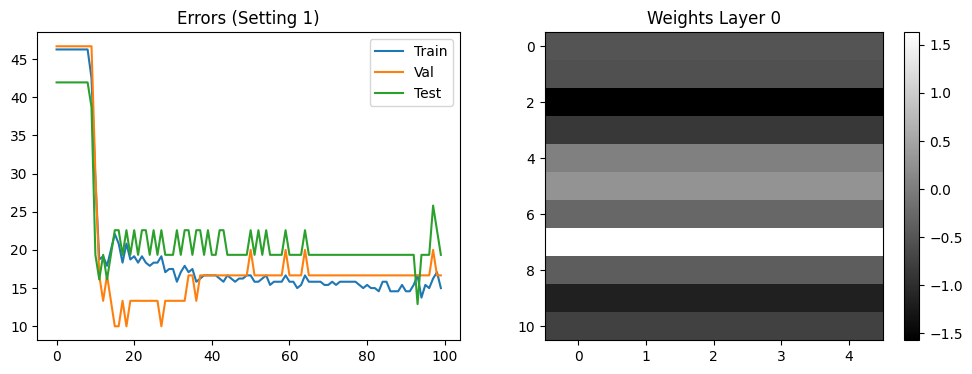

Confusion Matrices (Cleveland Test Set):
Iter 20:
[[15  3]
 [ 3 10]]
Iter 40:
[[14  4]
 [ 3 10]]
Iter 60:
[[13  5]
 [ 2 11]]
Iter 80:
[[15  3]
 [ 3 10]]
Iter 100:
[[15  3]
 [ 3 10]]

Cross-Dataset training/testing:
--- Trained on Cleveland ---
Tested on Hungarian CM:
[[ 9  4]
 [ 2 10]]
Tested on Switzerland CM:
[[ 0  1]
 [ 6 36]]
Tested on VA CM:
[[ 3  4]
 [ 4 20]]
--- Trained on Hungarian ---
Tested on Cleveland CM:
[[  0 163]
 [  0 138]]
Tested on Switzerland CM:
[[ 0  1]
 [ 0 42]]
Tested on VA CM:
[[ 0  7]
 [ 0 24]]
--- Trained on Switzerland ---
Tested on Cleveland CM:
[[  0 163]
 [  0 138]]
Tested on Hungarian CM:
[[ 0 13]
 [ 0 12]]
Tested on VA CM:
[[ 0  7]
 [ 0 24]]
--- Trained on VA ---
Tested on Cleveland CM:
[[  0 163]
 [  0 138]]
Tested on Hungarian CM:
[[ 0 13]
 [ 0 12]]
Tested on Switzerland CM:
[[ 0  1]
 [ 0 42]]

Combined datasets training:
Final Combined CM (Test Split):
[[37  7]
 [ 7 29]]


In [7]:
params_s1 = {
    'n_hidden': [5],
    'eta': 0.1,
    'maxIter': 100,
    'maxErr': 5,
    'percentOverfit': 30,
    'Train_Seg': 80,
    'Val_Seg': 10,
    'init_zero': True
}
evaluate_setting(params_s1, multi_class=False, title_suffix="(Setting 1)")


## Setting - 2
Increasing complexity: 2 hidden layers [5, 3].


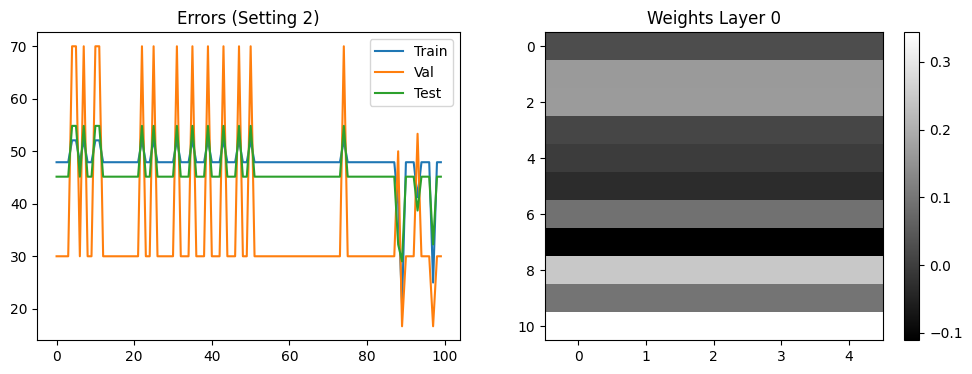

Confusion Matrices (Cleveland Test Set):
Iter 20:
[[17  0]
 [14  0]]
Iter 40:
[[ 0 17]
 [ 0 14]]
Iter 60:
[[17  0]
 [14  0]]
Iter 80:
[[17  0]
 [14  0]]
Iter 100:
[[17  0]
 [14  0]]

Cross-Dataset training/testing:
--- Trained on Cleveland ---
Tested on Hungarian CM:
[[12  1]
 [ 6  6]]
Tested on Switzerland CM:
[[ 1  0]
 [18 24]]
Tested on VA CM:
[[ 3  4]
 [11 13]]
--- Trained on Hungarian ---
Tested on Cleveland CM:
[[163   0]
 [138   0]]
Tested on Switzerland CM:
[[ 1  0]
 [42  0]]
Tested on VA CM:
[[ 7  0]
 [24  0]]
--- Trained on Switzerland ---
Tested on Cleveland CM:
[[  0 163]
 [  0 138]]
Tested on Hungarian CM:
[[ 0 13]
 [ 0 12]]
Tested on VA CM:
[[ 0  7]
 [ 0 24]]
--- Trained on VA ---
Tested on Cleveland CM:
[[  0 163]
 [  0 138]]
Tested on Hungarian CM:
[[ 0 13]
 [ 0 12]]
Tested on Switzerland CM:
[[ 0  1]
 [ 0 42]]

Combined datasets training:
Final Combined CM (Test Split):
[[31 10]
 [14 25]]


In [8]:
params_s2 = {
    'n_hidden': [5, 3],
    'eta': 0.1,
    'maxIter': 100,
    'maxErr': 5,
    'percentOverfit': 30,
    'Train_Seg': 80,
    'Val_Seg': 10,
    'init_zero': True
}
evaluate_setting(params_s2, multi_class=False, title_suffix="(Setting 2)")


## Setting - 3
Increasing generalization: split [60:20:20].


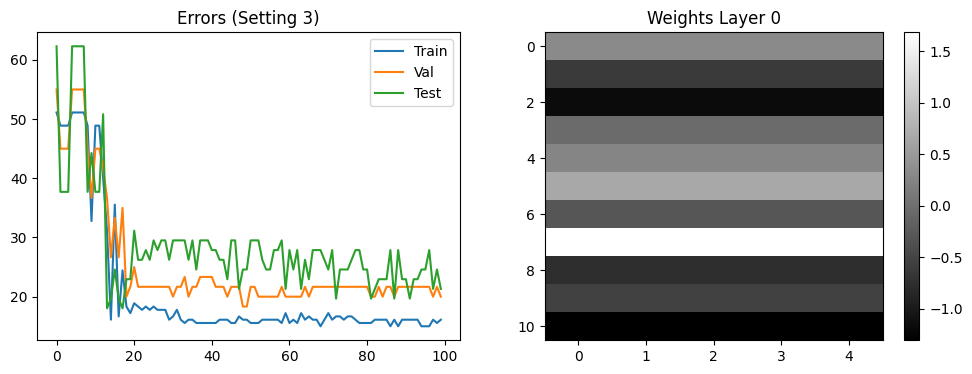

Confusion Matrices (Cleveland Test Set):
Iter 20:
[[29  9]
 [ 5 18]]
Iter 40:
[[24 14]
 [ 4 19]]
Iter 60:
[[29  9]
 [ 4 19]]
Iter 80:
[[27 11]
 [ 4 19]]
Iter 100:
[[29  9]
 [ 4 19]]

Cross-Dataset training/testing:
--- Trained on Cleveland ---
Tested on Hungarian CM:
[[ 9  4]
 [ 2 10]]
Tested on Switzerland CM:
[[ 0  1]
 [ 5 37]]
Tested on VA CM:
[[ 3  4]
 [ 4 20]]
--- Trained on Hungarian ---
Tested on Cleveland CM:
[[163   0]
 [138   0]]
Tested on Switzerland CM:
[[ 1  0]
 [42  0]]
Tested on VA CM:
[[ 7  0]
 [24  0]]
--- Trained on Switzerland ---
Tested on Cleveland CM:
[[  0 163]
 [  0 138]]
Tested on Hungarian CM:
[[ 0 13]
 [ 0 12]]
Tested on VA CM:
[[ 0  7]
 [ 0 24]]
--- Trained on VA ---
Tested on Cleveland CM:
[[  0 163]
 [  0 138]]
Tested on Hungarian CM:
[[ 0 13]
 [ 0 12]]
Tested on Switzerland CM:
[[ 0  1]
 [ 0 42]]

Combined datasets training:
Final Combined CM (Test Split):
[[34  7]
 [ 8 31]]


In [9]:
params_s3 = {
    'n_hidden': [5],
    'eta': 0.1,
    'maxIter': 100,
    'maxErr': 5,
    'percentOverfit': 30,
    'Train_Seg': 60,
    'Val_Seg': 20,
    'init_zero': True
}
evaluate_setting(params_s3, multi_class=False, title_suffix="(Setting 3)")


## Setting - 4
Learning rate decay: alpha=0.9, LR_decay_freq=20.


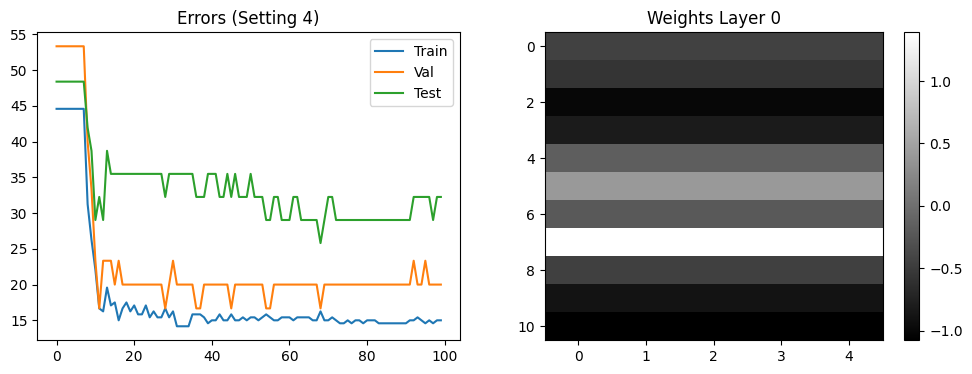

Confusion Matrices (Cleveland Test Set):
Iter 20:
[[ 8  8]
 [ 3 12]]
Iter 40:
[[ 8  8]
 [ 3 12]]
Iter 60:
[[10  6]
 [ 3 12]]
Iter 80:
[[10  6]
 [ 3 12]]
Iter 100:
[[ 9  7]
 [ 3 12]]

Cross-Dataset training/testing:
--- Trained on Cleveland ---
Tested on Hungarian CM:
[[ 9  4]
 [ 1 11]]
Tested on Switzerland CM:
[[ 0  1]
 [ 5 37]]
Tested on VA CM:
[[ 3  4]
 [ 4 20]]
--- Trained on Hungarian ---
Tested on Cleveland CM:
[[163   0]
 [138   0]]
Tested on Switzerland CM:
[[ 1  0]
 [42  0]]
Tested on VA CM:
[[ 7  0]
 [24  0]]
--- Trained on Switzerland ---
Tested on Cleveland CM:
[[  0 163]
 [  0 138]]
Tested on Hungarian CM:
[[ 0 13]
 [ 0 12]]
Tested on VA CM:
[[ 0  7]
 [ 0 24]]
--- Trained on VA ---
Tested on Cleveland CM:
[[  0 163]
 [  0 138]]
Tested on Hungarian CM:
[[ 0 13]
 [ 0 12]]
Tested on Switzerland CM:
[[ 0  1]
 [ 0 42]]

Combined datasets training:
Final Combined CM (Test Split):
[[24  2]
 [ 7 47]]


In [10]:
params_s4 = {
    'n_hidden': [5],
    'eta': 0.1,
    'alpha': 0.9,
    'LR_decay_freq': 20,
    'maxIter': 100,
    'maxErr': 5,
    'percentOverfit': 30,
    'Train_Seg': 80,
    'Val_Seg': 10,
    'init_zero': True
}
evaluate_setting(params_s4, multi_class=False, title_suffix="(Setting 4)")


## Setting - 5
Multiclass classification: using Setting 2 model on all heart-disease classes.


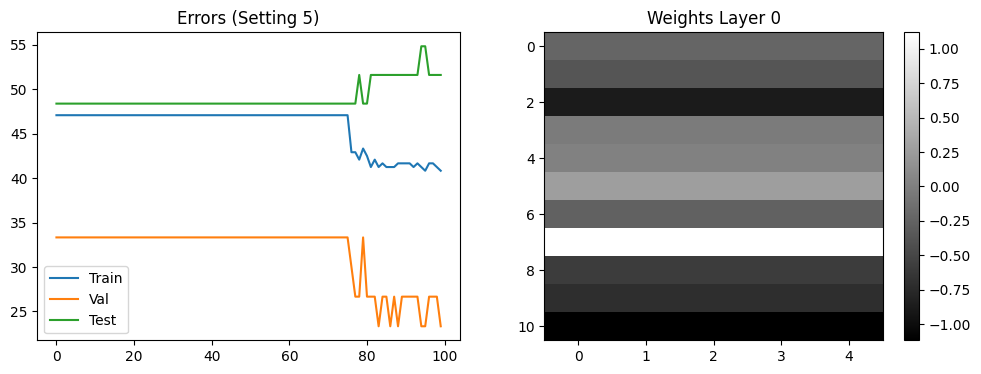

Confusion Matrices (Cleveland Test Set):
Iter 20:
[[16  0  0  0  0]
 [ 5  0  0  0  0]
 [ 6  0  0  0  0]
 [ 3  0  0  0  0]
 [ 1  0  0  0  0]]
Iter 40:
[[16  0  0  0  0]
 [ 5  0  0  0  0]
 [ 6  0  0  0  0]
 [ 3  0  0  0  0]
 [ 1  0  0  0  0]]
Iter 60:
[[16  0  0  0  0]
 [ 5  0  0  0  0]
 [ 6  0  0  0  0]
 [ 3  0  0  0  0]
 [ 1  0  0  0  0]]
Iter 80:
[[16  0  0  0  0]
 [ 5  0  0  0  0]
 [ 4  2  0  0  0]
 [ 1  2  0  0  0]
 [ 1  0  0  0  0]]
Iter 100:
[[14  2  0  0  0]
 [ 4  1  0  0  0]
 [ 2  4  0  0  0]
 [ 0  3  0  0  0]
 [ 1  0  0  0  0]]

Cross-Dataset training/testing:
--- Trained on Cleveland ---
Tested on Hungarian CM:
[[9 2 2 0 0]
 [4 3 5 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Tested on Switzerland CM:
[[1 0 0 0 0]
 [4 1 7 0 0]
 [5 1 6 0 0]
 [4 2 9 0 0]
 [0 0 3 0 0]]
Tested on VA CM:
[[3 0 4 0 0]
 [4 1 9 0 0]
 [2 2 4 0 0]
 [0 0 2 0 0]
 [0 0 0 0 0]]
--- Trained on Hungarian ---
Tested on Cleveland CM:
[[163   0   0   0   0]
 [ 55   0   0   0   0]
 [ 35   0   0   0   0]
 [ 35   0

In [11]:
params_s5 = {
    'n_hidden': [5, 3],
    'eta': 0.1,
    'maxIter': 100,
    'maxErr': 5,
    'percentOverfit': 30,
    'Train_Seg': 80,
    'Val_Seg': 10,
    'init_zero': True
}
evaluate_setting(params_s5, multi_class=True, title_suffix="(Setting 5)")


## Handling Missing Data

In [12]:
def get_highest_density_estimate(d1, xb, xg, xg_val, is_xb_discrete):
    if d1.empty:
        return None
    
    if is_xb_discrete:
        is_xg_discrete = len(d1[xg].unique()) <= 10
        if is_xg_discrete:
            matches = d1[d1[xg] == xg_val]
            if not matches.empty:
                return matches[xb].mode()[0]
        
        idx = (d1[xg] - xg_val).abs().nsmallest(min(10, len(d1))).index
        return d1.loc[idx, xb].mode()[0]
    else:
        idx = (d1[xg] - xg_val).abs().nsmallest(min(10, len(d1))).index
        nearest_xb = d1.loc[idx, xb]
        if len(nearest_xb) > 1:
            counts, bin_edges = np.histogram(nearest_xb, bins=min(5, len(nearest_xb)))
            max_bin = np.argmax(counts)
            return (bin_edges[max_bin] + bin_edges[max_bin+1]) / 2
        return nearest_xb.mean()

def handle_missing_data(df_orig, plot=False):
    df = df_orig.copy().replace('?', np.nan)
    df = df.drop(columns=['slope', 'ca'])
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    discrete_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'thal', 'num']
    
    fallbacks = {}
    for col in df.columns:
        if col in discrete_cols:
            fallbacks[col] = df[col].mode()[0] if not df[col].mode().empty else 0
        else:
            fallbacks[col] = df[col].mean()
            
    global_corrs = df.corr().abs()
    
    while df.isnull().any().any():
        null_mask = df.isnull().any(axis=1)
        idx = df[null_mask].index[0]
        row = df.loc[idx]
        
        missing_cols = row.index[row.isnull()].tolist()
        xb = missing_cols[0]
        target_class = row['num']
        
        d1 = df.dropna()
        d1_class = d1[d1['num'] == target_class]
        if len(d1_class) >= 5:
            d1 = d1_class
        elif len(d1) < 5:
            df.at[idx, xb] = fallbacks[xb]
            continue
            
        xg = 'age'
        try:
            corrs = d1.corr()[xb].abs().drop([xb, 'num'], errors='ignore').dropna()
            if not corrs.empty:
                xg = corrs.idxmax()
            else:
                corrs_g = global_corrs[xb].drop([xb, 'num'], errors='ignore').dropna()
                if not corrs_g.empty:
                    xg = corrs_g.idxmax()
        except:
            pass
        
        if plot:
            plt.figure(figsize=(6, 4))
            if xb in discrete_cols and xg in discrete_cols:
                plt.hist2d(d1[xg], d1[xb], bins=[len(d1[xg].unique()), len(d1[xb].unique())], cmap='Blues')
                plt.title(f'2D Histogram: {xg} vs {xb} (Class {target_class})')
            else:
                plt.scatter(d1[xg], d1[xb], alpha=0.5)
                plt.title(f'2D Scatter: {xg} vs {xb} (Class {target_class})')
            plt.xlabel(xg); plt.ylabel(xb)
            plt.savefig(f"fig{next(fig_id)}.png", bbox_inches="tight")
            plt.show()
            plot = False
            
        is_xb_discrete = xb in discrete_cols
        est_val = get_highest_density_estimate(d1, xb, xg, row[xg], is_xb_discrete)
        if est_val is None:
            est_val = fallbacks[xb]
            
        df.at[idx, xb] = est_val
            
    return df

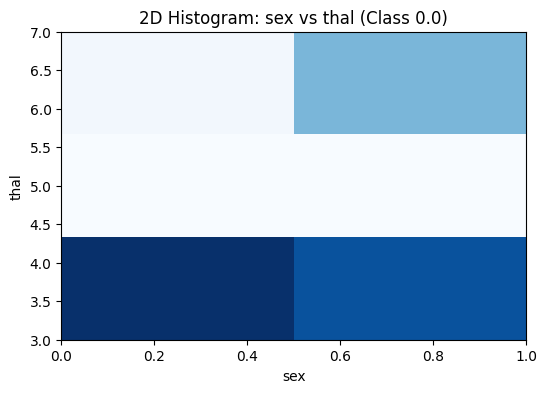

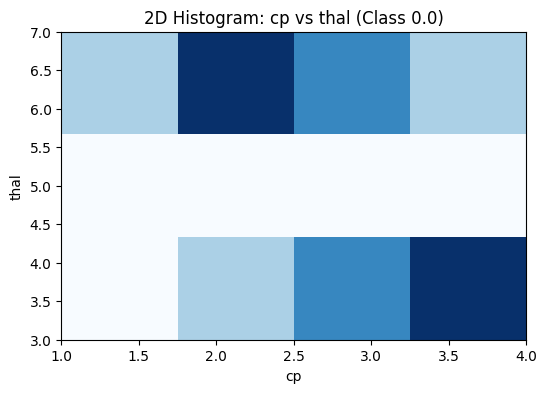

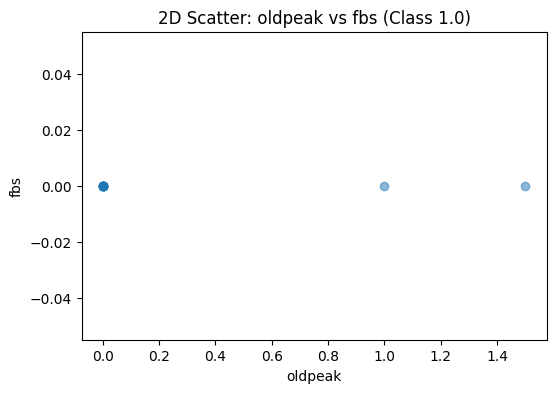

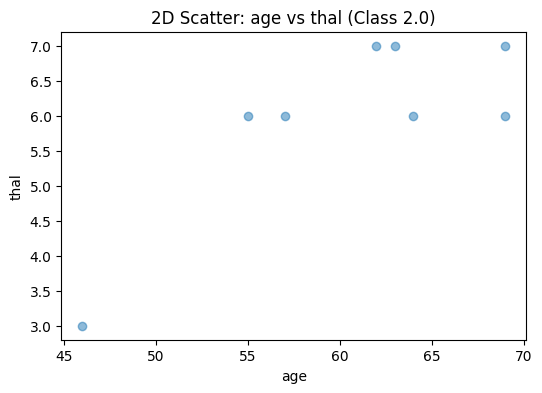

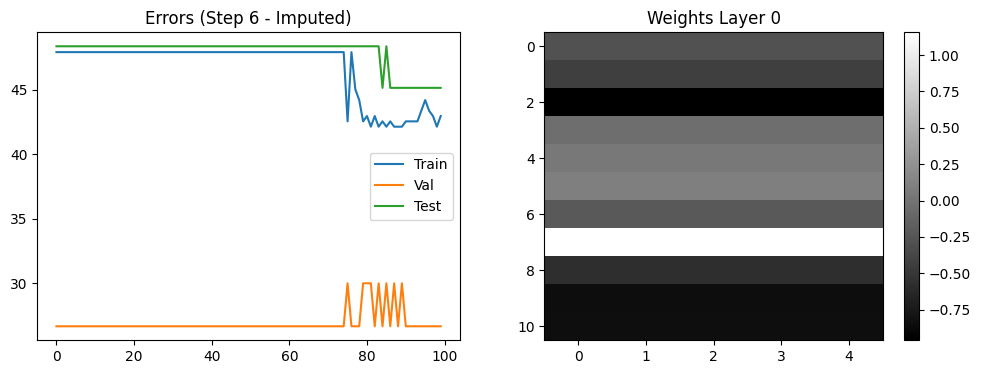

Confusion Matrices (Cleveland Test Set):
Iter 20:
[[16  0  0  0  0]
 [ 5  0  0  0  0]
 [ 2  0  0  0  0]
 [ 7  0  0  0  0]
 [ 1  0  0  0  0]]
Iter 40:
[[16  0  0  0  0]
 [ 5  0  0  0  0]
 [ 2  0  0  0  0]
 [ 7  0  0  0  0]
 [ 1  0  0  0  0]]
Iter 60:
[[16  0  0  0  0]
 [ 5  0  0  0  0]
 [ 2  0  0  0  0]
 [ 7  0  0  0  0]
 [ 1  0  0  0  0]]
Iter 80:
[[16  0  0  0  0]
 [ 5  0  0  0  0]
 [ 2  0  0  0  0]
 [ 3  4  0  0  0]
 [ 1  0  0  0  0]]
Iter 100:
[[16  0  0  0  0]
 [ 4  1  0  0  0]
 [ 1  1  0  0  0]
 [ 2  3  2  0  0]
 [ 1  0  0  0  0]]

Cross-Dataset training/testing:
--- Trained on Cleveland ---
Tested on Hungarian CM:
[[183   5   0   0   0]
 [ 28  18   0  60   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]]
Tested on Switzerland CM:
[[ 4  3  0  1  0]
 [17 13  0 18  0]
 [17  2  0 13  0]
 [ 5  6  0 19  0]
 [ 1  0  0  4  0]]
Tested on VA CM:
[[24 14  0 13  0]
 [12  8  0 36  0]
 [ 6 11  0 24  0]
 [ 5  4  0 33  0]
 [ 0  1  0  9  0]]
--- Trained on Hungarian ---
Te

In [14]:
df1_imputed = handle_missing_data(df1, plot=True)
df2_imputed = handle_missing_data(df2, plot=True)
df3_imputed = handle_missing_data(df3, plot=True)
df4_imputed = handle_missing_data(df4, plot=True)

params_s6 = {
    'n_hidden': [5, 3],
    'eta': 0.1,
    'maxIter': 100,
    'maxErr': 5,
    'percentOverfit': 30,
    'Train_Seg': 80,
    'Val_Seg': 10,
    'init_zero': True
}

old_dfs = [df1_clean, df2_clean, df3_clean, df4_clean]
df1_clean, df2_clean, df3_clean, df4_clean = df1_imputed, df2_imputed, df3_imputed, df4_imputed
evaluate_setting(params_s6, multi_class=True, title_suffix="(Step 6 - Imputed)")
df1_clean, df2_clean, df3_clean, df4_clean = old_dfs